In [160]:
import pandas as pd
import duckdb
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [161]:
PATH = "results"
PROC_DIR = Path(f"../artifacts/{PATH}")
#OUT_PATH = Path(f"output/{'_'.join(PATH.split('/'))}_info.tsv")
#OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(PROC_DIR)
files = sorted(PROC_DIR.glob("*_comparison.csv"))
files

../artifacts/results


[PosixPath('../artifacts/results/level_01_daily_total_sales_model_comparison.csv'),
 PosixPath('../artifacts/results/level_04_daily_dept_sales_model_comparison.csv'),
 PosixPath('../artifacts/results/level_06_daily_store_sales_model_comparison.csv'),
 PosixPath('../artifacts/results/level_09_daily_store_dept_sales_model_comparison.csv')]

In [162]:
sample = files[0]
sample

PosixPath('../artifacts/results/level_01_daily_total_sales_model_comparison.csv')

In [163]:
df_results = []
for file in files:
    print(file)
    filename = file.stem
    parts = filename.split("__")
    base = parts[0]
    split = base.split("_")
    stats = {"level": split[1], "grainly": split[2]}
    print(stats)
    df = pd.read_csv(file)
    df['level'] = stats['level']
    df['level'] = df['level'].astype(int)
    df['grainly'] = stats['grainly']

    df_results.append(df)

df_results = pd.concat(df_results, ignore_index=True)
df_results

../artifacts/results/level_01_daily_total_sales_model_comparison.csv
{'level': '01', 'grainly': 'daily'}
../artifacts/results/level_04_daily_dept_sales_model_comparison.csv
{'level': '04', 'grainly': 'daily'}
../artifacts/results/level_06_daily_store_sales_model_comparison.csv
{'level': '06', 'grainly': 'daily'}
../artifacts/results/level_09_daily_store_dept_sales_model_comparison.csv
{'level': '09', 'grainly': 'daily'}


,model,category,wape,wrmsse,mae,rmse,smape,bias,rmsle,tracking_signal,spec,mase,fit_time,level,grainly
0,XGBoost,ML,0.038860,0.366459,1642.696847,2166.756650,0.039003,-0.000388,0.049984,0.279383,1744.734410,0.386270,2.931755,1,daily
1,SARIMA,Statistical,0.056911,0.501102,2405.771822,2962.861762,0.056779,-0.016928,0.067699,8.328342,11536.470336,0.565702,6.928417,1,daily
2,ETS (Holt-Winters),Statistical,0.057486,0.506892,2430.068402,2997.095171,0.057519,-0.014464,0.069258,7.045020,10098.978409,0.571415,5.068504,1,daily
3,Seasonal naive (28d),Naive,0.057615,0.520748,2435.535714,3079.021650,0.058385,-0.006386,0.074777,3.103629,3488.616071,0.572701,0.006029,1,daily
4,TBATS,Statistical,0.060291,0.542923,2548.641089,3210.133232,0.060201,0.001970,0.074641,-0.914827,3806.505434,0.599297,17.178362,1,daily
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Drift,Naive,0.285428,1.687304,172.367601,300.898078,0.299698,0.099197,0.382097,-681.175487,4323.299495,1.981865,0.053772,9,daily
80,XGBoost,ML,0.371604,1.957210,224.408347,365.843772,0.474007,-0.196886,0.844582,1038.462711,15385.007480,2.410446,9.471157,9,daily
81,LightGBM,ML,0.433533,2.129352,261.806505,464.539965,0.510944,-0.164729,0.934481,744.740452,20877.100011,2.616431,8.943759,9,daily
82,HistGradientBoosting,ML,0.512661,2.519306,309.591446,465.272971,0.606533,-0.064492,1.045624,246.563583,21420.041477,3.170071,11.218402,9,daily


In [164]:
df_mean_level = df_results.groupby(['level']).mean(numeric_only=True).reset_index().round(3)

df_mean_level['models'] =  df_results.groupby(['level'])['model'].nunique().values

df_mean_level

,level,wape,wrmsse,mae,rmse,smape,bias,rmsle,tracking_signal,spec,mase,fit_time,models
0,1,0.105,0.918,4448.677,5428.491,0.105,-0.027,0.126,7.191,28294.602,1.046,2.444,21
1,4,0.180,1.387,1089.273,1763.096,0.213,-0.044,0.316,35.234,33628.193,1.607,4.136,21
2,6,0.143,1.066,606.203,819.043,0.141,-0.032,0.182,60.469,7564.372,1.213,5.433,21
3,9,0.236,1.390,142.618,247.294,0.278,-0.059,0.410,419.418,5627.827,1.610,10.162,21


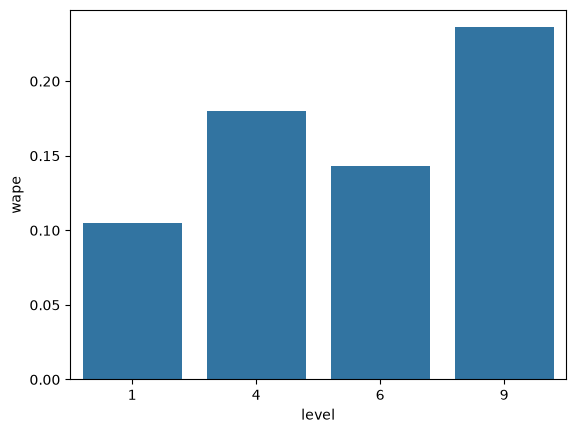

In [165]:
sns.barplot(df_mean_level, x='level', y='wape')
plt.show()

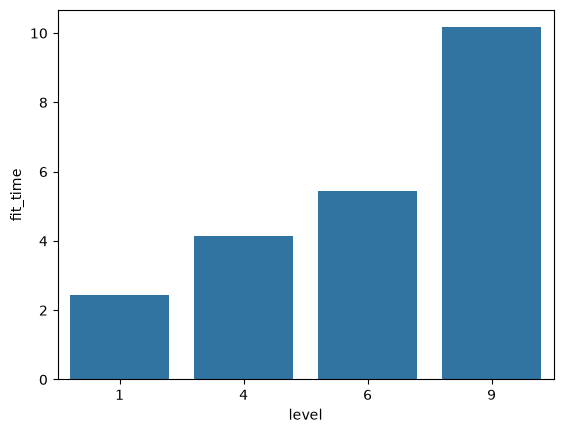

In [166]:
sns.barplot(df_mean_level, x='level', y='fit_time')
plt.show()

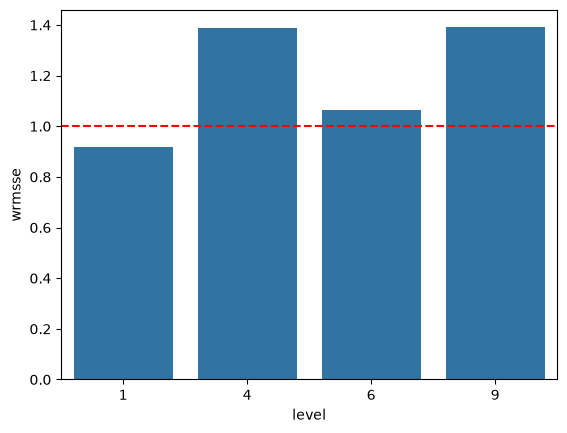

In [167]:
sns.barplot(df_mean_level, x='level', y='wrmsse')
plt.axhline(1, color='red', linestyle='--')
plt.show()

# Levels

In [173]:
levels = df_results['level'].unique()
df_results = df_results.sort_values(['level','category','model'])

def plot_metric_level(metric, df_results=df_results, levels=levels):
    
    for level in levels:
        df_level = df_results.query(f'level == {level}')[['level','category','model', metric]]
        df_level = df_level.sort_values(metric)
        palette = {'Naive': '#55A868', 'ML': '#4C72B0', 'Statistical': '#DD8452'}
        orden = ['ML', 'Naive', 'Statistical']
        
        plt.figure(figsize=(14, 5))
        plt.title(f"nivel={level} metrica={metric}")
        
        sns.barplot(df_level, x='model', y=metric, hue='category', hue_order=orden, palette=palette)
        
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()

In [174]:
df_results.columns

Index(['model', 'category', 'wape', 'wrmsse', 'mae', 'rmse', 'smape', 'bias',
       'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time', 'level',
       'grainly'],
      dtype='str')

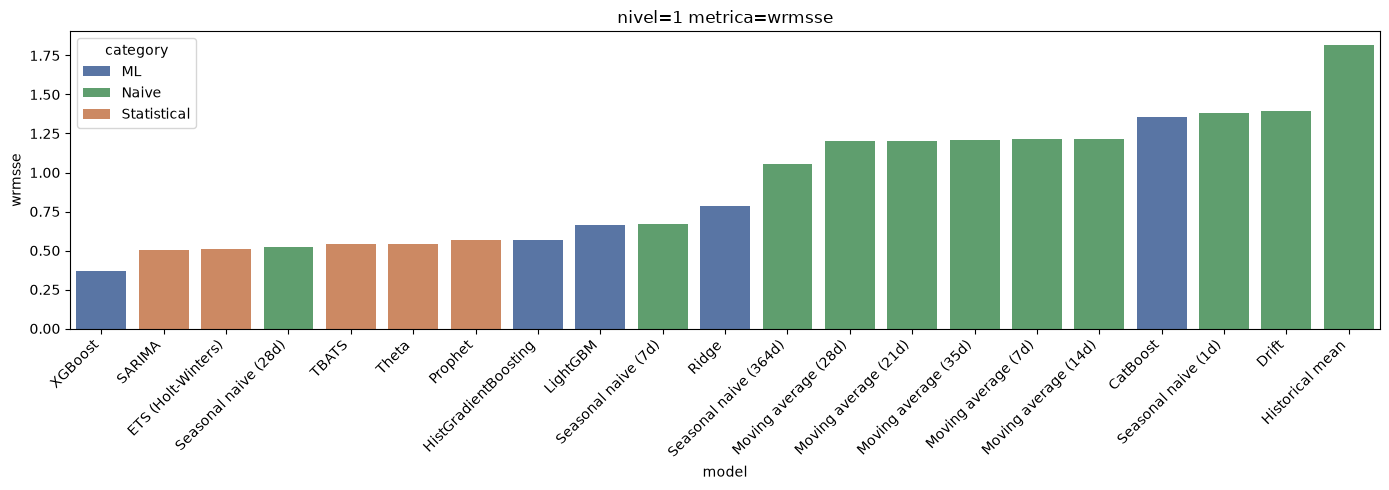

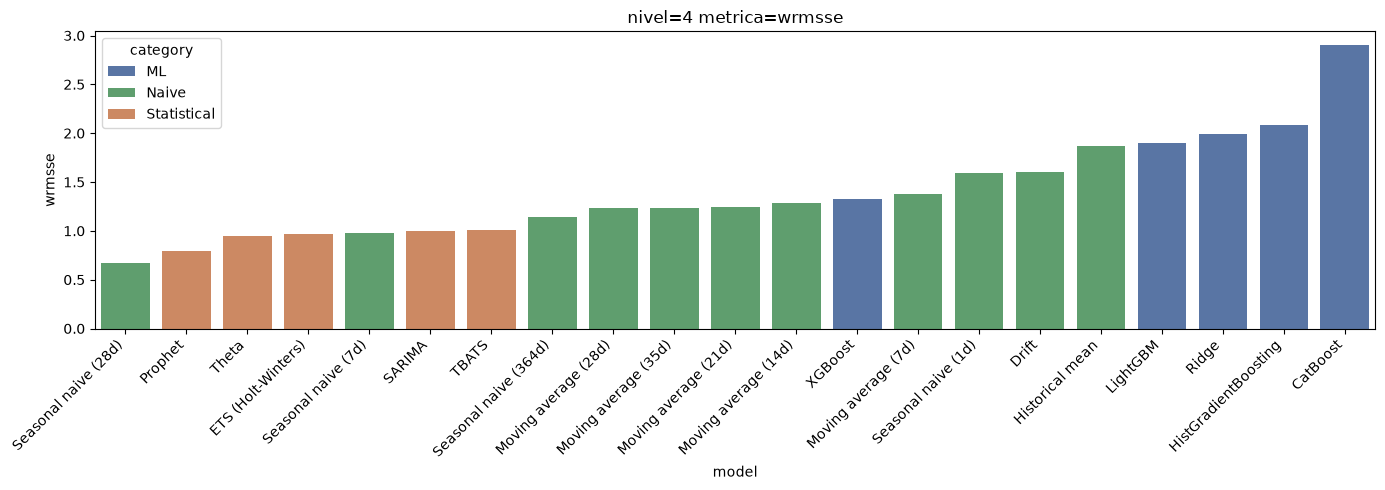

In [ ]:
plot_metric_level('wrmsse')

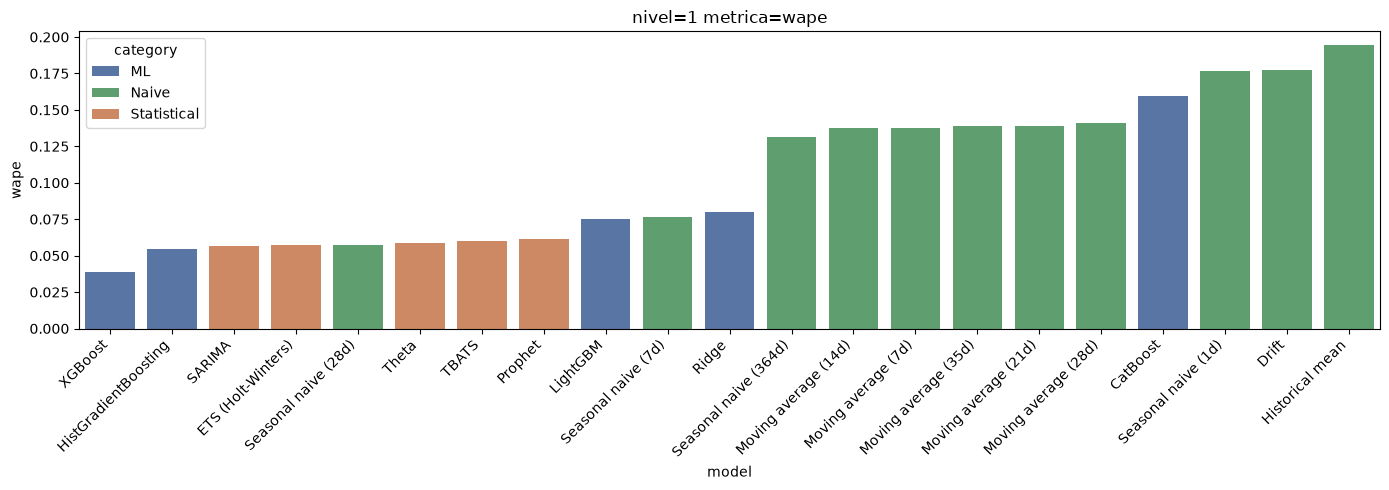

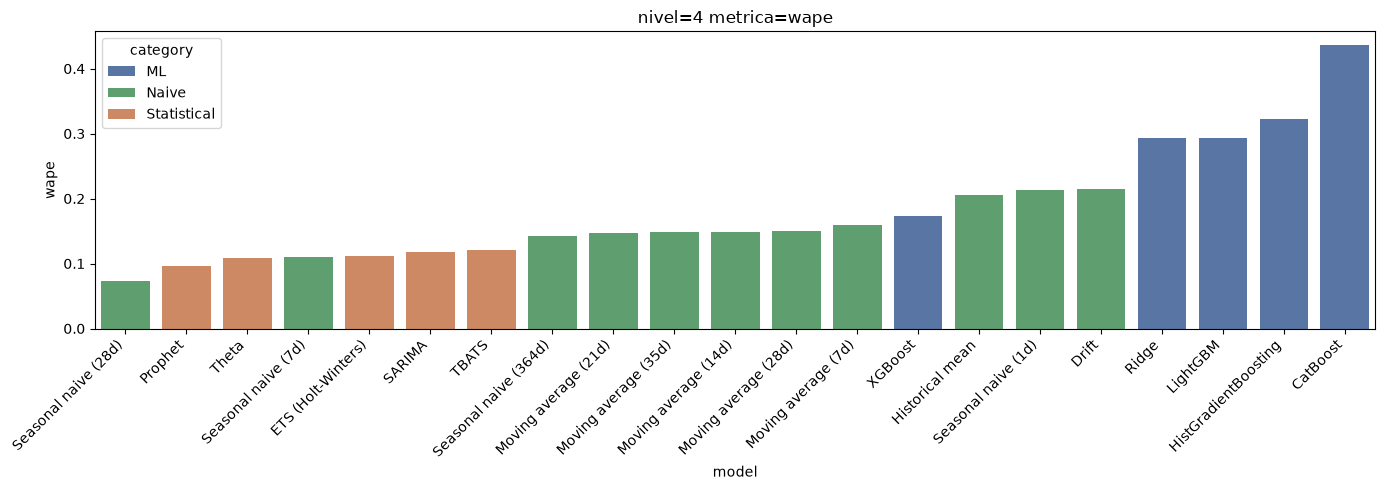

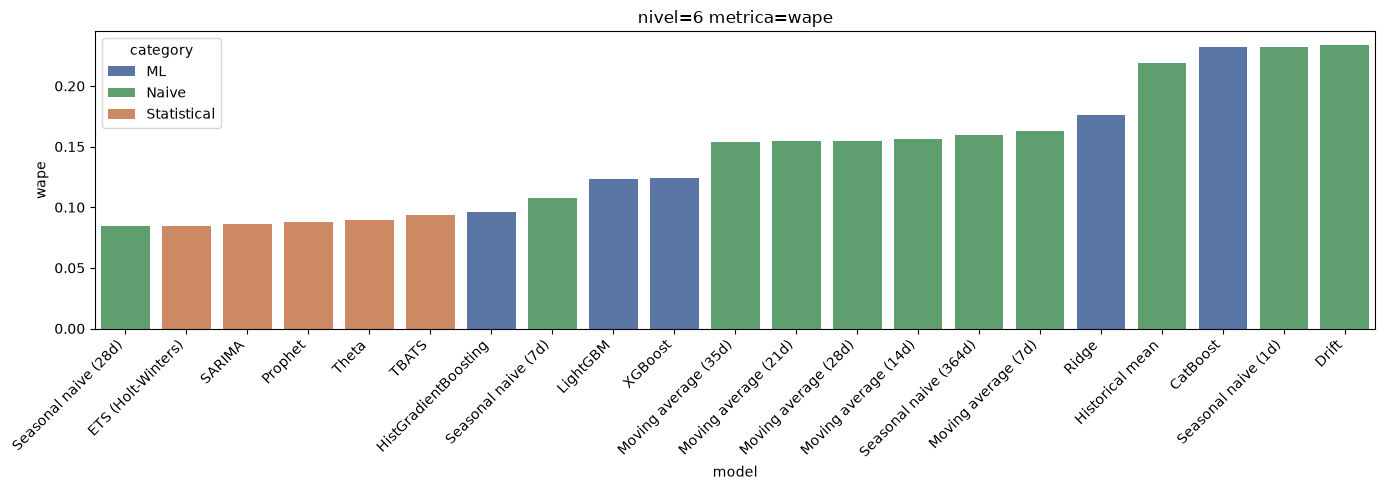

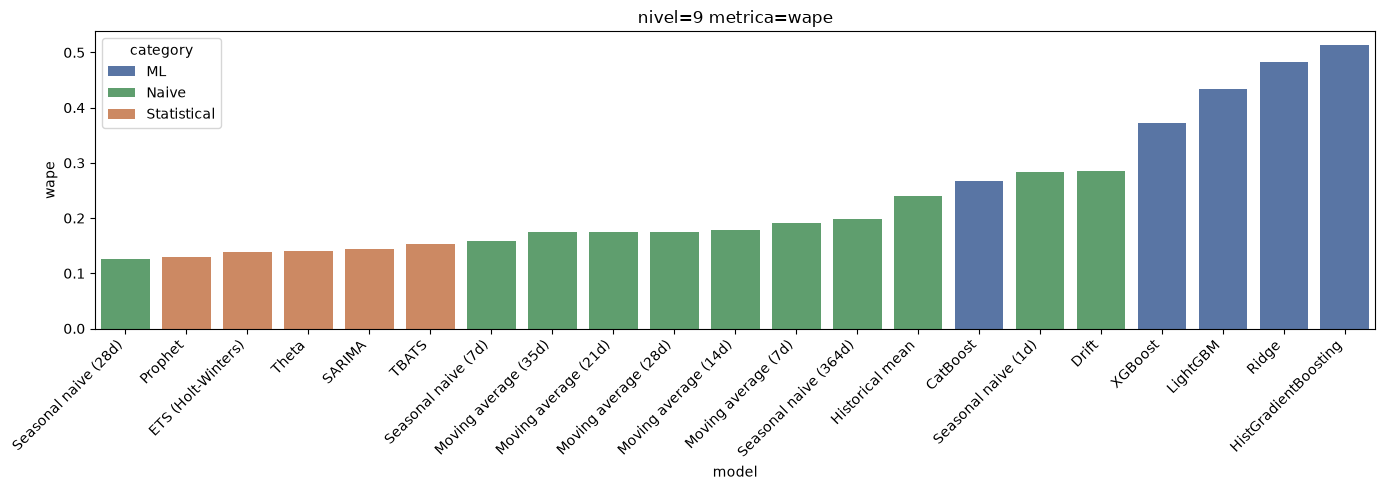

In [175]:
plot_metric_level('wape')

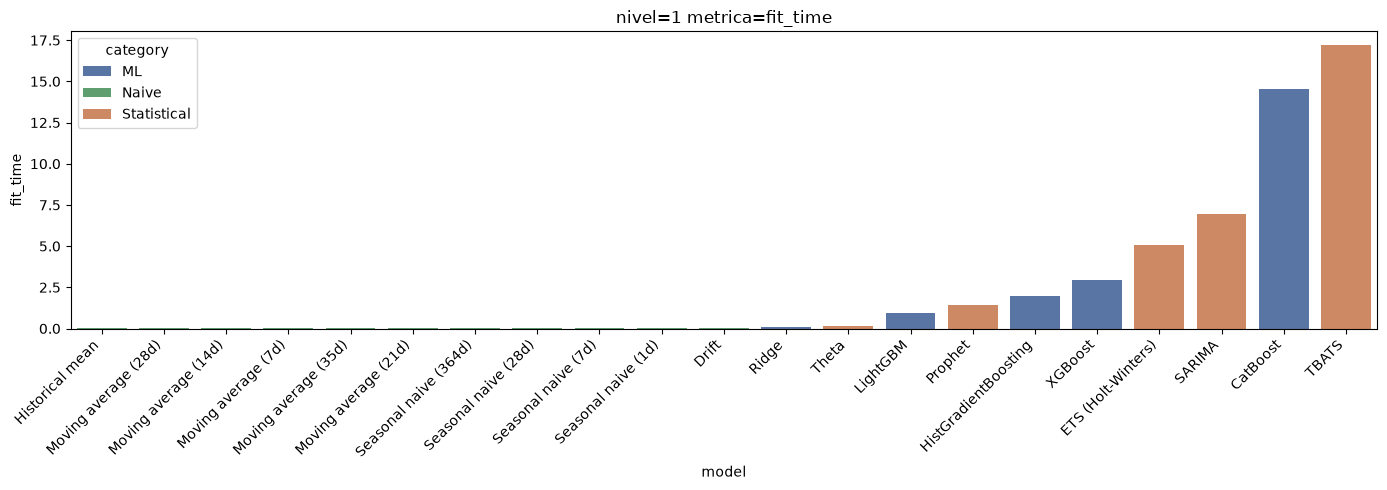

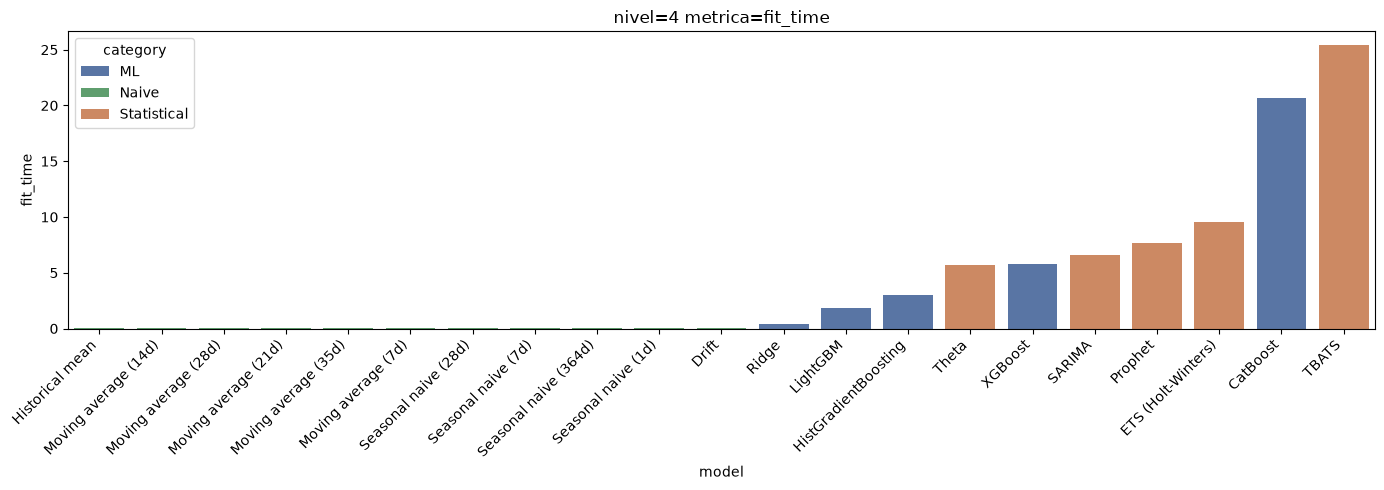

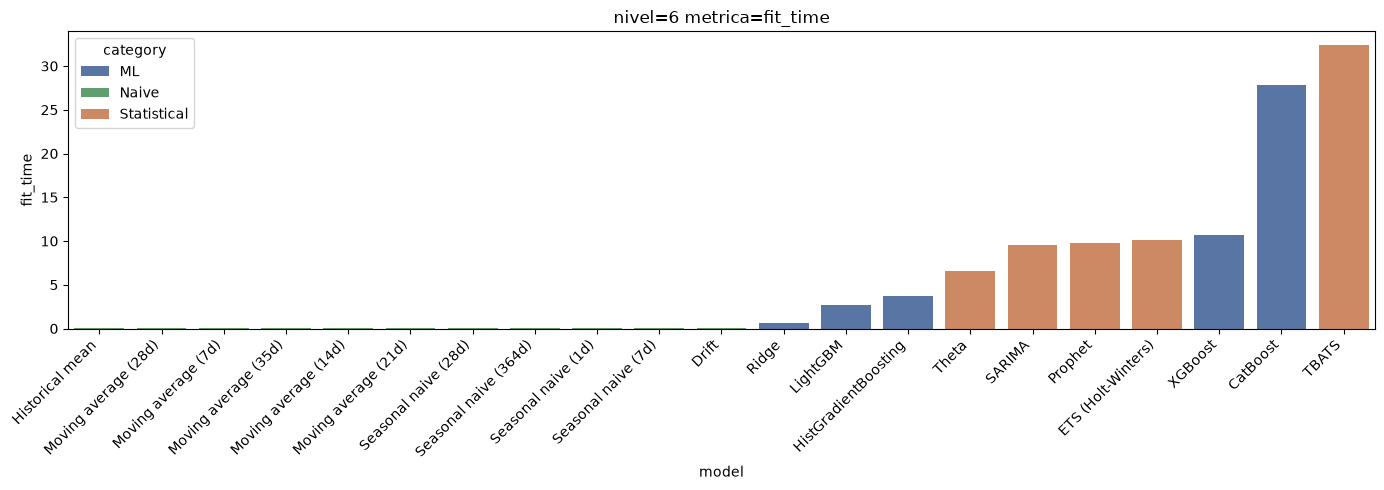

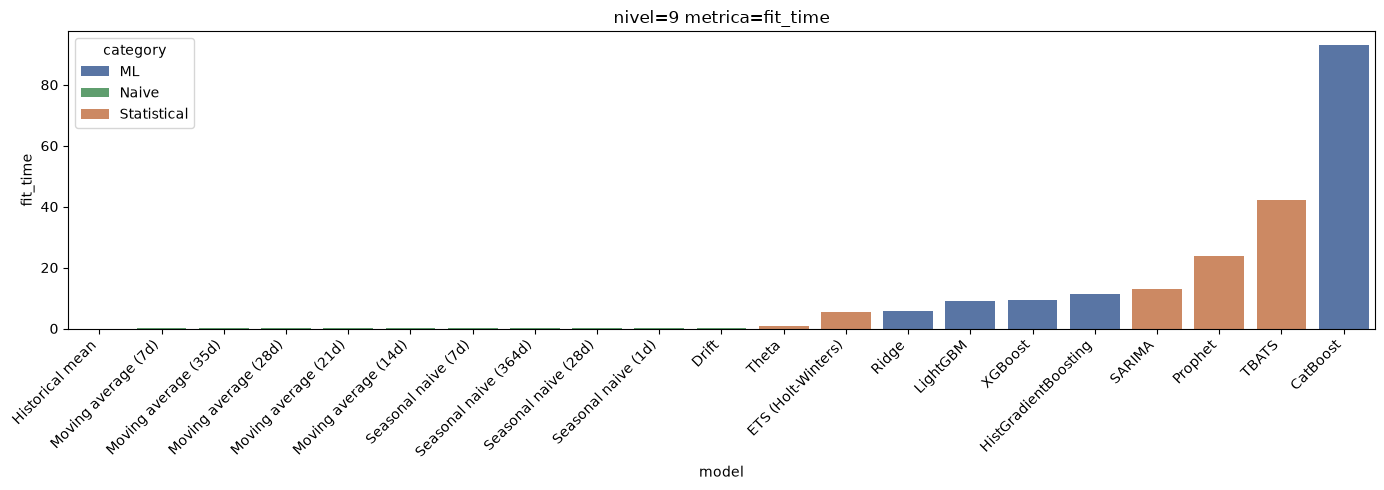

In [179]:
plot_metric_level('fit_time')